In [2]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from pathlib import Path
import spacy
import re
from tqdm import tqdm

# Add the parent directory to sys.path so src can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.utils as utils

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("crest")

# Cargar todos los conjuntos de datos 

In [4]:
file_path = r"..\data\results\ciencia_chunks.xlsx"
fragmentos_ciencia = pd.read_excel(file_path, engine='openpyxl')

file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus_cleaned = pd.read_excel(file_path2, engine='openpyxl')

chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

In [5]:
chunks_df.columns

Index(['id_doc', 'autor_doc', 'fecha_doc', 'diario_doc', 'titulo_doc',
       'chunk_id', 'texto_chunk'],
      dtype='object')

In [6]:
fragmentos_ciencia.columns

Index(['chunk_id', 'id_doc', 'texto_chunk', 'Ciencias_ambientales_ingenieria',
       'Ciencias_espacio', 'Ciencias_fisicas',
       'Ciencias_Geografia_oceanografia', 'Ciencias_medicas',
       'Ciencias_metereologia', 'Ciencias_naturales',
       'Ciencias_polucion_catastrofes_seguridad', 'Ciencias_quimicas',
       'Ciencias_tierra', 'Ciencia_Administracion_ciencia_investigacion',
       'Ciencia_biologia', 'Ciencia_enfoque_cientifico', 'Ciencia_hidrologia',
       'Ciencia_matematicas_estadistica', 'Ciencia_patologia',
       'Ciencia_recursos_naturales', 'categorias_detectadas'],
      dtype='object')

In [7]:
# Unir metadatos del corpus
fragmentos_ciencia = fragmentos_ciencia.merge(
    corpus_cleaned[["ID", "Autor", "Diario", "Fecha", "Título"]],
    left_on="id_doc",
    right_on="ID",
    how="left"
)

In [8]:
fragmentos_ciencia.drop(columns=["ID"], inplace=True)

In [9]:
# Asegurar tipos
fragmentos_ciencia["Fecha"] = pd.to_datetime(fragmentos_ciencia["Fecha"], errors="coerce")
fragmentos_ciencia["Año"] = fragmentos_ciencia["Fecha"].dt.year
fragmentos_ciencia["Mes"] = fragmentos_ciencia["Fecha"].dt.month

# Estadísticos básicos

In [10]:
# Total de fragmentos, total documentos únicos
len(chunks_df), len(chunks_df["id_doc"].unique())

(35319, 13676)

In [11]:
# Total de fragmentos de ciencia, total documentos únicos donde aparecen
len(fragmentos_ciencia), len(fragmentos_ciencia["id_doc"].unique())

(4287, 3004)

In [12]:
# Porcentaje de fragmentos de ciencia sobre el total
(4287/35319)*100

12.137942750360995

In [13]:
# Porcentaje de documentos con al menos un fragmento de ciencia
(3004/13676)*100

21.96548698449839

In [14]:
# Contar cuántos fragmentos de ciencia tiene cada columna
conteo_fragmentos = fragmentos_ciencia["id_doc"].value_counts().reset_index()
conteo_fragmentos.columns = ["id_doc", "num_fragmentos_ciencia"]
conteo_fragmentos

,id_doc,num_fragmentos_ciencia
0,13272,8
1,13142,8
2,12999,8
3,13067,7
4,13032,7
...,...,...
2999,3977,1
3000,3976,1
3001,13564,1
3002,13560,1


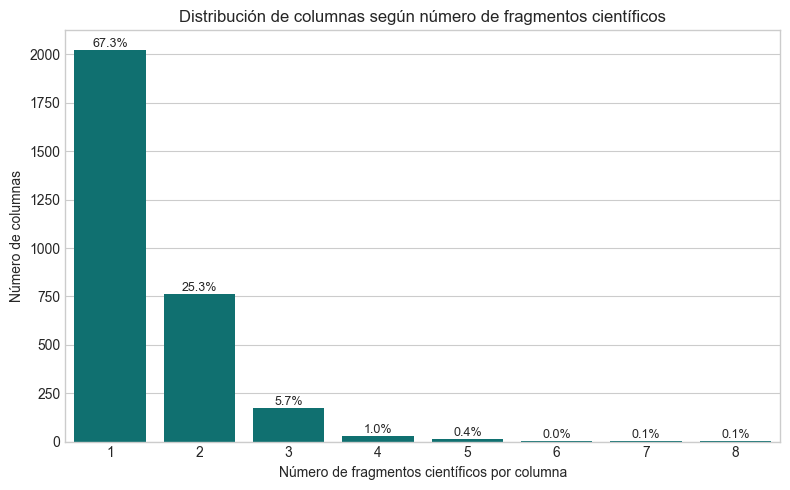

       num_columnas  porcentaje
count                          
1              2023       67.34
2               761       25.33
3               172        5.73
4                30        1.00
5                11        0.37
6                 1        0.03
7                 3        0.10
8                 3        0.10


In [15]:
# Distribución: cuántas columnas tienen 1, 2, 3... fragmentos
distribucion = fragmentos_ciencia["id_doc"].value_counts().value_counts().sort_index()
porcentajes = distribucion / distribucion.sum() * 100

plt.figure(figsize=(8,5))
ax = sns.barplot(x=distribucion.index, y=distribucion.values, color="teal")

for i, (x, y) in enumerate(zip(distribucion.index, distribucion.values)):
    ax.text(i, y + 0.5, f"{porcentajes.iloc[i]:.1f}%", ha="center", va="bottom", fontsize=9)

plt.title("Distribución de columnas según número de fragmentos científicos")
plt.xlabel("Número de fragmentos científicos por columna")
plt.ylabel("Número de columnas")
plt.tight_layout()
plt.savefig(r"..\reports\ideas PAPERS\figures\dist_cols_ciencia.png", dpi=300, bbox_inches="tight")
plt.show()

print(distribucion.to_frame("num_columnas").assign(porcentaje=porcentajes.round(2)))

In [16]:
# ================================================
# PROMEDIO DE CHUNKS POR COLUMNA Y PROPORCIÓN DE CIENCIA
# ================================================

# Calcular número total de chunks por columna en el corpus completo
chunks_por_columna = chunks_df["id_doc"].value_counts().reset_index()
chunks_por_columna.columns = ["id_doc", "num_chunks_totales"]

# Unir con conteo de fragmentos de ciencia
df_ratio_ciencia = conteo_fragmentos.merge(chunks_por_columna, on="id_doc", how="left")

# Calcular proporción
df_ratio_ciencia["proporcion_ciencia"] = (
    df_ratio_ciencia["num_fragmentos_ciencia"] / df_ratio_ciencia["num_chunks_totales"]
)

print("\nEstadísticos de proporción de ciencia por columna:")
display(df_ratio_ciencia["proporcion_ciencia"].describe())



Estadísticos de proporción de ciencia por columna:


count    3004.000000
mean        0.554127
std         0.250328
min         0.111111
25%         0.333333
50%         0.500000
75%         0.666667
max         1.000000
Name: proporcion_ciencia, dtype: float64

In [17]:
chunks_por_columna["num_chunks_totales"].value_counts().sort_index()


num_chunks_totales
1      574
2     6732
3     4883
4     1053
5      320
6       58
7       26
8       17
9        9
11       1
20       1
21       2
Name: count, dtype: int64

In [18]:
# ================================================
# PROMEDIO DE CHUNKS POR COLUMNA
# ================================================

promedio_chunks = df_ratio_ciencia["num_chunks_totales"].mean()
promedio_fragmentos = df_ratio_ciencia["num_fragmentos_ciencia"].mean()
promedio_prop_ciencia = df_ratio_ciencia["proporcion_ciencia"].mean()

print(f"\nPromedio de chunks por columna: {promedio_chunks:.2f}")
print(f"Promedio de fragmentos de ciencia por columna: {promedio_fragmentos:.2f}")
print(f"Promedio de proporción de ciencia: {promedio_prop_ciencia*100:.2f}%")



Promedio de chunks por columna: 2.74
Promedio de fragmentos de ciencia por columna: 1.43
Promedio de proporción de ciencia: 55.41%


# Distribución temporal

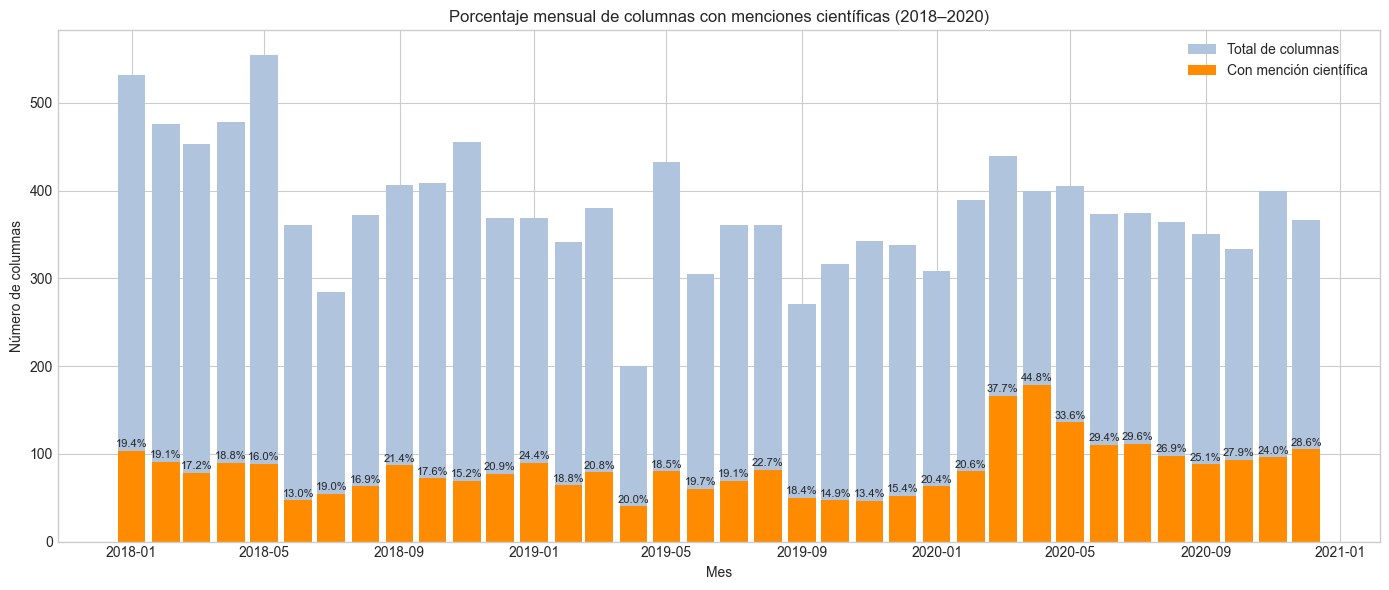

,total_columnas,columnas_ciencia,porcentaje
AñoMes,,,
2020-01-01,309,63,20.39
2020-02-01,389,80,20.57
2020-03-01,440,166,37.73
2020-04-01,400,179,44.75
2020-05-01,405,136,33.58
2020-06-01,374,110,29.41
2020-07-01,375,111,29.60
2020-08-01,364,98,26.92
2020-09-01,351,88,25.07


In [19]:
# Agrupar por mes-año
corpus_cleaned["AñoMes"] = corpus_cleaned["Fecha"].dt.to_period("M")
fragmentos_ciencia["AñoMes"] = fragmentos_ciencia["Fecha"].dt.to_period("M")

# Total de columnas y columnas con ciencia por mes
totales = corpus_cleaned.groupby("AñoMes")["ID"].nunique()
con_ciencia = fragmentos_ciencia.groupby("AñoMes")["id_doc"].nunique()

# Combinar en un DataFrame
mensual = pd.DataFrame({
    "total_columnas": totales,
    "columnas_ciencia": con_ciencia
}).fillna(0)

mensual["porcentaje"] = (mensual["columnas_ciencia"] / mensual["total_columnas"] * 100).round(2)
mensual.index = mensual.index.to_timestamp()  # para graficar

# ================================================
# GRÁFICO DE BARRAS APILADO
# ================================================
plt.figure(figsize=(14,6))
plt.bar(mensual.index, mensual["total_columnas"], color="lightsteelblue", label="Total de columnas", width=25)
plt.bar(mensual.index, mensual["columnas_ciencia"], color="darkorange", label="Con mención científica", width=25)

# Porcentajes
for x, y_total, y_ciencia, pct in zip(mensual.index, mensual["total_columnas"],
                                      mensual["columnas_ciencia"], mensual["porcentaje"]):
    if y_ciencia > 0:
        plt.text(x, y_ciencia + 2, f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

plt.title("Porcentaje mensual de columnas con menciones científicas (2018–2020)")
plt.ylabel("Número de columnas")
plt.xlabel("Mes")
plt.legend()
plt.tight_layout()


# Guardar figura
plt.savefig(r"..\reports\ideas PAPERS\figures\porcentaje_mensual_ciencia.png", dpi=300, bbox_inches="tight")
plt.show()

# Mostrar tabla resumen
display(mensual.tail(12))


# Autores
Autores con más columnas con menciones cientificas

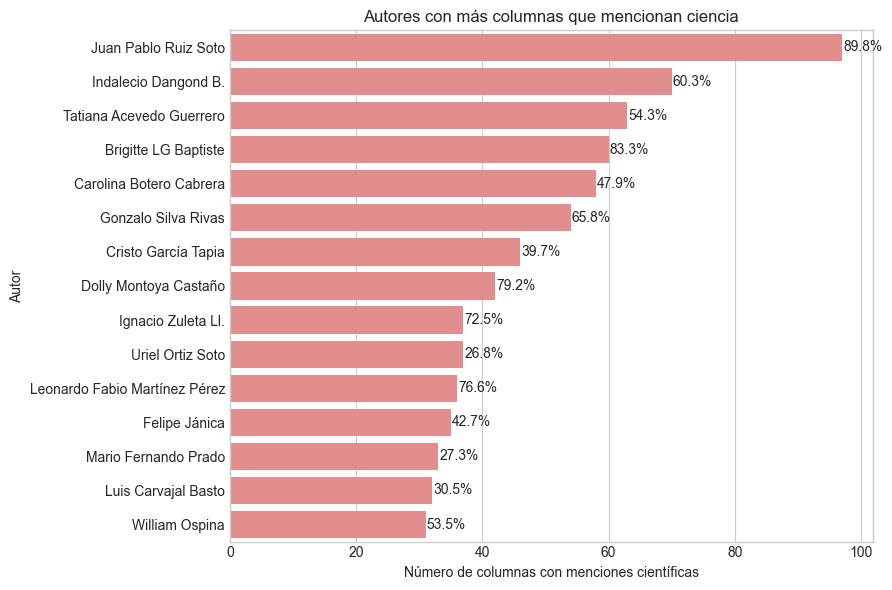

In [20]:
# Contar cuántas columnas distintas mencionan ciencia por autor
autores_ciencia = (
    fragmentos_ciencia.groupby("Autor")["id_doc"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="num_columnas_ciencia")
)

# Total de columnas por autor en todo el corpus
autores_totales = (
    corpus_cleaned.groupby("Autor")["ID"]
    .nunique()
    .reset_index(name="total_columnas")
)

# Unir ambos y calcular proporción
autores_merge = autores_ciencia.merge(autores_totales, on="Autor", how="left")
autores_merge["porcentaje_ciencia"] = (
    autores_merge["num_columnas_ciencia"] / autores_merge["total_columnas"] * 100
).round(2)

# Mostrar top 15
top_autores = autores_merge.head(15)


# ================================================
# GRÁFICO
# ================================================
plt.figure(figsize=(9,6))
orden = top_autores.sort_values("num_columnas_ciencia", ascending=False)["Autor"]

sns.barplot(
    data=top_autores,
    y="Autor",
    x="num_columnas_ciencia",
    order=orden,
    color="lightcoral"
)

for i, (n, p) in enumerate(zip(top_autores["num_columnas_ciencia"], top_autores["porcentaje_ciencia"])):
    plt.text(n + 0.2, i, f"{p:.1f}%", va="center", fontsize=10)

plt.title("Autores con más columnas que mencionan ciencia")
plt.xlabel("Número de columnas con menciones científicas")
plt.ylabel("Autor")
plt.tight_layout()

plt.savefig(r"..\reports\ideas PAPERS\figures\autores_ciencia.png", dpi=300, bbox_inches="tight")
plt.show()

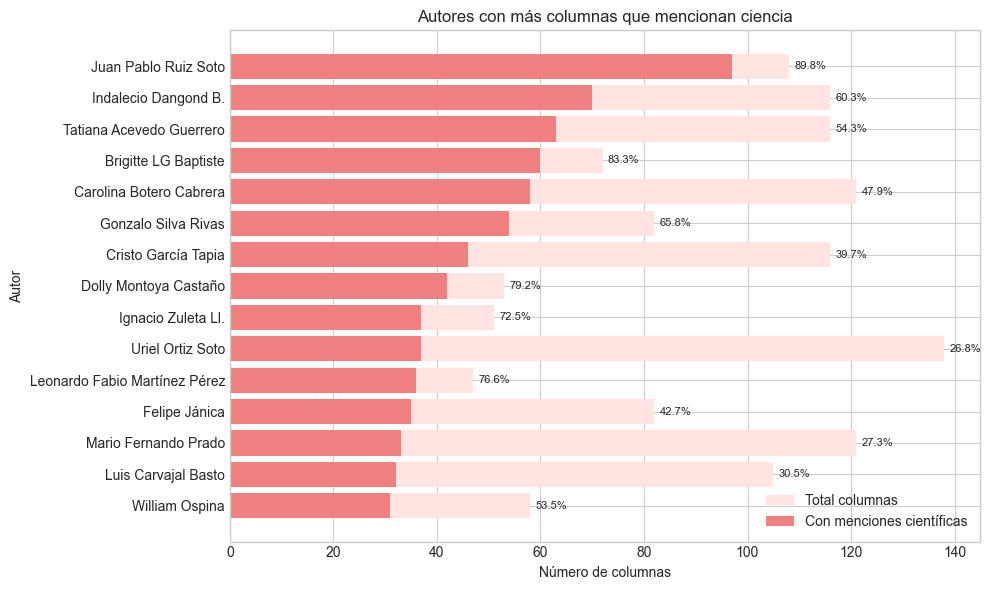

In [21]:
# ================================================
# GRÁFICO COMPARATIVO: TOTAL vs. CON MENCIONES CIENTÍFICAS
# ================================================

# Asegurar el orden del ranking
top_autores_sorted = top_autores.sort_values("num_columnas_ciencia", ascending=True)

plt.figure(figsize=(10,6))

# Barras grises (total columnas)
plt.barh(top_autores_sorted["Autor"], top_autores_sorted["total_columnas"],
         color="mistyrose", label="Total columnas")

# Barras teal (columnas con ciencia)
plt.barh(top_autores_sorted["Autor"], top_autores_sorted["num_columnas_ciencia"],
         color="lightcoral", label="Con menciones científicas")

# Añadir porcentajes
for i, (n, t, p) in enumerate(zip(
    top_autores_sorted["num_columnas_ciencia"],
    top_autores_sorted["total_columnas"],
    top_autores_sorted["porcentaje_ciencia"]
)):
    plt.text(t + 1, i, f"{p:.1f}%", va="center", fontsize=8)

plt.title("Autores con más columnas que mencionan ciencia")
plt.xlabel("Número de columnas")
plt.ylabel("Autor")
plt.legend()
plt.tight_layout()
plt.savefig(r"..\reports\ideas PAPERS\figures\autores_ciencia_comparativo.png", dpi=300, bbox_inches="tight")
plt.show()


In [22]:
top_autores

,Autor,num_columnas_ciencia,total_columnas,porcentaje_ciencia
0,Juan Pablo Ruiz Soto,97,108,89.81
1,Indalecio Dangond B.,70,116,60.34
2,Tatiana Acevedo Guerrero,63,116,54.31
3,Brigitte LG Baptiste,60,72,83.33
4,Carolina Botero Cabrera,58,121,47.93
5,Gonzalo Silva Rivas,54,82,65.85
6,Cristo García Tapia,46,116,39.66
7,Dolly Montoya Castaño,42,53,79.25
8,Ignacio Zuleta Ll.,37,51,72.55
9,Uriel Ortiz Soto,37,138,26.81


# Por subcategorías

In [23]:
fragmentos_ciencia.columns

Index(['chunk_id', 'id_doc', 'texto_chunk', 'Ciencias_ambientales_ingenieria',
       'Ciencias_espacio', 'Ciencias_fisicas',
       'Ciencias_Geografia_oceanografia', 'Ciencias_medicas',
       'Ciencias_metereologia', 'Ciencias_naturales',
       'Ciencias_polucion_catastrofes_seguridad', 'Ciencias_quimicas',
       'Ciencias_tierra', 'Ciencia_Administracion_ciencia_investigacion',
       'Ciencia_biologia', 'Ciencia_enfoque_cientifico', 'Ciencia_hidrologia',
       'Ciencia_matematicas_estadistica', 'Ciencia_patologia',
       'Ciencia_recursos_naturales', 'categorias_detectadas', 'Autor',
       'Diario', 'Fecha', 'Título', 'Año', 'Mes', 'AñoMes'],
      dtype='object')

In [24]:
# Identificar las columnas de subcategorías (todas las que comienzan con 'Ciencia')
subcats_cols = [
    c for c in fragmentos_ciencia.columns
    if c.startswith("Ciencia") or c.startswith("Ciencias_")
]
len(subcats_cols)
# Obtener la subcategoría con mayor score por fila
fragmentos_ciencia["subcategoria_max"] = fragmentos_ciencia[subcats_cols].idxmax(axis=1)

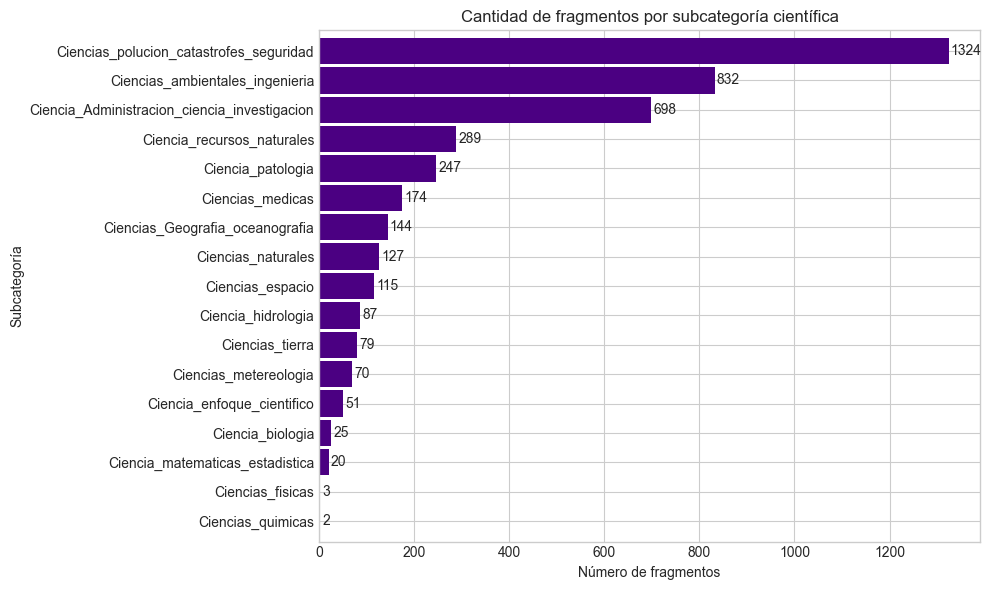

In [25]:
plt.figure(figsize=(10,6))

# Crear gráfico y guardar el eje
ax = fragmentos_ciencia["subcategoria_max"].value_counts().sort_values().plot.barh(color="indigo", width=0.9)

# Etiquetas de conteo al final de cada barra
for i, v in enumerate(fragmentos_ciencia["subcategoria_max"].value_counts().sort_values().values):
    ax.text(v + 5, i, str(v), va="center", fontsize=10)

plt.title("Cantidad de fragmentos por subcategoría científica")
plt.xlabel("Número de fragmentos")
plt.ylabel("Subcategoría")
plt.tight_layout()
plt.savefig(r"..\reports\ideas PAPERS\figures\subcategorias_principales.png", dpi=300, bbox_inches="tight")
plt.show()

Columnas por subcategoría:

subcategoria_max
Ciencias_polucion_catastrofes_seguridad         1134
Ciencias_ambientales_ingenieria                  631
Ciencia_Administracion_ciencia_investigacion     538
Ciencia_recursos_naturales                       251
Ciencia_patologia                                232
Ciencias_medicas                                 146
Ciencias_Geografia_oceanografia                  123
Ciencias_naturales                               116
Ciencias_espacio                                  99
Ciencia_hidrologia                                78
Ciencias_tierra                                   76
Ciencias_metereologia                             66
Ciencia_enfoque_cientifico                        51
Ciencia_biologia                                  23
Ciencia_matematicas_estadistica                   18
Ciencias_fisicas                                   3
Ciencias_quimicas                                  2
Name: id_doc, dtype: int64


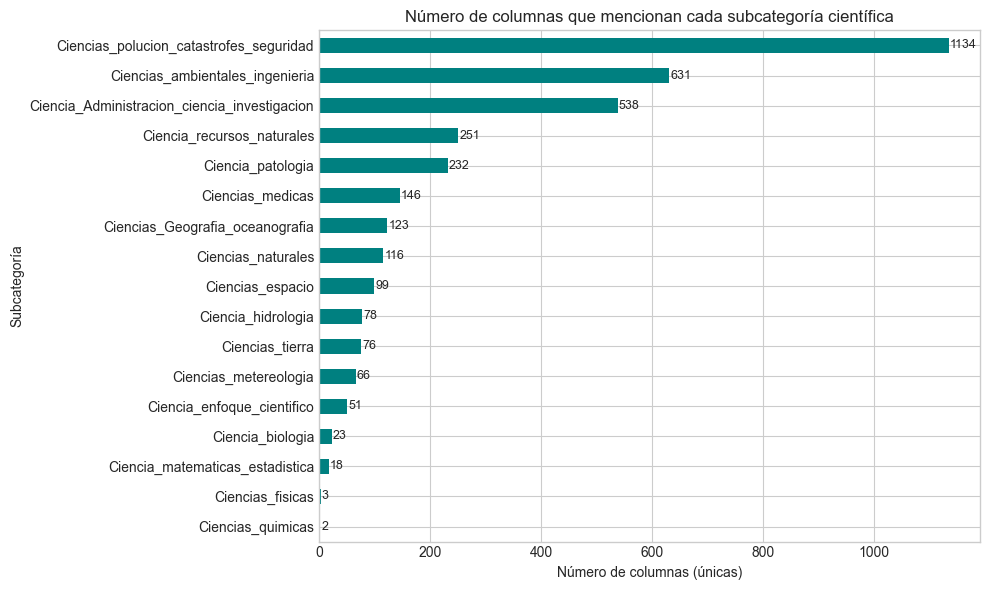

In [26]:
# ================================================
# NÚMERO DE COLUMNAS POR SUBCATEGORÍA PRINCIPAL
# ================================================

# Contar cuántas columnas distintas (id_doc) tienen al menos un fragmento de cada subcategoría
columnas_por_subcat = (
    fragmentos_ciencia.groupby("subcategoria_max")["id_doc"]
    .nunique()
    .sort_values(ascending=False)
)

# Mostrar tabla resumen
print("Columnas por subcategoría:\n")
print(columnas_por_subcat)

# ================================================
# GRÁFICO
# ================================================
plt.figure(figsize=(10,6))
ax = columnas_por_subcat.sort_values().plot.barh(color="teal")

# Añadir etiquetas de número
for i, v in enumerate(columnas_por_subcat.sort_values().values):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)

plt.title("Número de columnas que mencionan cada subcategoría científica")
plt.xlabel("Número de columnas (únicas)")
plt.ylabel("Subcategoría")
plt.tight_layout()
# plt.savefig(r"..\reports\ideas PAPERS\figures\columnas_por_subcategoria.png", dpi=300, bbox_inches="tight")
plt.show()


# Nubes de Palabras

In [27]:
nlp = spacy.load("es_core_news_sm")
# Stopwords en español
STOP_WORDS = nlp.Defaults.stop_words

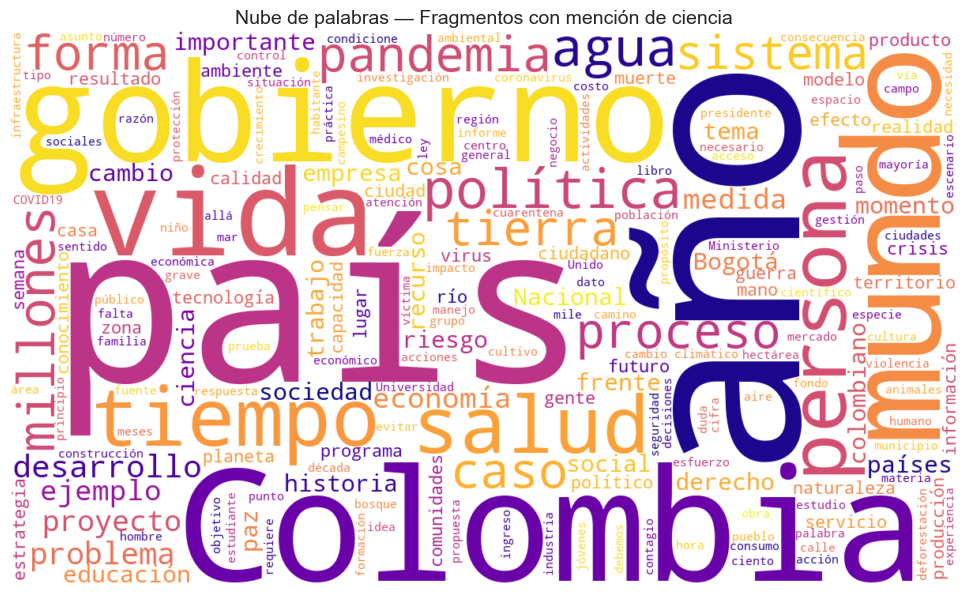

In [28]:
# ================================================
# NUBE DE PALABRAS — FRAGMENTOS CON CIENCIA
# ================================================
textos_ciencia = " ".join(fragmentos_ciencia["texto_chunk"].astype(str))

wordcloud_ciencia = WordCloud(
    width=1200, height=700,
    background_color="white",
    stopwords=STOP_WORDS,
    colormap="plasma"
).generate(textos_ciencia)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud_ciencia, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — Fragmentos con mención de ciencia", fontsize=14)
plt.tight_layout()
plt.savefig(r"..\reports\ideas PAPERS\figures\nube_ciencia_fragmentos.png", dpi=300, bbox_inches="tight")
plt.show()

# Tablas de palabras más frecuentes

In [29]:
def obtener_frecuencias(textos, stopwords, n=None, lematizar=False):
    # --- Preprocesamiento básico ---
    texto_unido = " ".join(map(str, textos)).lower()
    tokens = re.findall(r"\b[a-záéíóúüñ]+\b", texto_unido)
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

    # --- Si no se quiere lematizar ---
    if not lematizar:
        return Counter(tokens).most_common(n)

    # --- Si se activa lematización ---
    print(" Lematizando textos, esto puede tardar unos minutos...")
    lemas = []
    for doc in tqdm(nlp.pipe(tokens, batch_size=500, disable=["ner", "parser"], n_process=2),
                    total=len(tokens), desc="Lematizando"):
        lemas.extend([t.lemma_.lower() for t in doc if t.is_alpha and len(t) > 2])

    return Counter([l for l in lemas if l not in stopwords]).most_common(n)


In [30]:
# --- obtener frecuencias sin truncar ---
df_corpus = pd.DataFrame(
    obtener_frecuencias(corpus_cleaned["Texto"], STOP_WORDS, n=None),
    columns=["palabra", "frecuencia_corpus"]
)

df_ciencia = pd.DataFrame(
    obtener_frecuencias(fragmentos_ciencia["texto_chunk"], STOP_WORDS, n=None),
    columns=["palabra", "frecuencia_ciencia"]
)

columnas_con_ciencia = fragmentos_ciencia["id_doc"].unique()
textos_columnas_ciencia = corpus_cleaned[corpus_cleaned["ID"].isin(columnas_con_ciencia)]["Texto"]

df_columnas = pd.DataFrame(
    obtener_frecuencias(textos_columnas_ciencia, STOP_WORDS, n=None),
    columns=["palabra", "frecuencia_columnas"]
)

# --- merge completo ---
tabla_frecuencias = (
    df_corpus.merge(df_ciencia, on="palabra", how="outer")
             .merge(df_columnas, on="palabra", how="outer")
             .fillna(0)
)

# --- convertir a enteros ---
tabla_frecuencias[["frecuencia_corpus", "frecuencia_ciencia", "frecuencia_columnas"]] = (
    tabla_frecuencias[["frecuencia_corpus", "frecuencia_ciencia", "frecuencia_columnas"]].astype(int)
)

# --- añadir proporciones respecto a la frecuencia del corpus ---
# evitar división por cero
tabla_frecuencias["proporcion_ciencia"] = (
    tabla_frecuencias.apply(
        lambda r: r["frecuencia_ciencia"] / r["frecuencia_corpus"] if r["frecuencia_corpus"] > 0 else 0,
        axis=1
    )
)

tabla_frecuencias["proporcion_columnas"] = (
    tabla_frecuencias.apply(
        lambda r: r["frecuencia_columnas"] / r["frecuencia_corpus"] if r["frecuencia_corpus"] > 0 else 0,
        axis=1
    )
)

# --- ordenar por frecuencia científica ---
tabla_top = tabla_frecuencias.sort_values("frecuencia_ciencia", ascending=False).head(30)


tabla_top.head(20)

,palabra,frecuencia_corpus,frecuencia_ciencia,frecuencia_columnas,proporcion_ciencia,proporcion_columnas
93195,país,16307,2157,3734,0.132274,0.228981
26471,colombia,14604,1871,3302,0.128116,0.226102
86201,nacional,7499,1597,2418,0.212962,0.322443
15007,años,13137,1564,2855,0.119053,0.217325
85744,mundo,8676,1547,2533,0.178308,0.291955
61814,gobierno,14310,1528,2757,0.106778,0.192662
112596,salud,3958,1373,1924,0.346892,0.486104
128460,vida,8455,1313,2248,0.155293,0.265878
37679,desarrollo,3621,1138,1629,0.314278,0.449876
83366,millones,5939,1063,1717,0.178986,0.289106


In [31]:
# ================================================
# TABLA REDUCIDA PARA LATEX (corpus, columnas, proporción)
# ================================================

# Crear tabla reducida
tabla_latex = tabla_top[["palabra", "frecuencia_corpus", "frecuencia_columnas", "proporcion_columnas"]].copy()

# Redondear proporciones
tabla_latex["proporcion_columnas"] = tabla_latex["proporcion_columnas"].round(2)

tabla_latex.rename(columns={
    "palabra": "Palabra",
    "frecuencia_corpus": "Freq. corpus",
    "frecuencia_columnas": "Freq. columnas ciencia",
    "proporcion_columnas": "Proporción columnas"
}, inplace=True)

# Crear carpeta si no existe
output_dir = Path(r"..\reports\ideas PAPERS\tablas")
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar como archivo .tex compatible con LaTeX
latex_path = output_dir / "tabla_frecuencias_columnas.tex"

with open(latex_path, "w", encoding="utf-8") as f:
    f.write(
        tabla_latex.to_latex(
            index=False,
            caption="Palabras más frecuentes en columnas con mención científica respecto al corpus.",
            label="tab:frecuencias_columnas",
            float_format="%.2f",
            escape=False,
            position="H"
        )
    )

print(f"✅ Tabla LaTeX guardada en: {latex_path}")


✅ Tabla LaTeX guardada en: ..\reports\ideas PAPERS\tablas\tabla_frecuencias_columnas.tex


# Tablas completas

ANTES DE CORRER REVISAR LO DE LEMATIZAR, PONER EN FALSE O CARGAR los archivos

In [9]:
# Rutas
data_dir = Path(r"..\data\processed")

# Cargar desde parquet
df_corpus = pd.read_parquet(data_dir / "frecuencias_corpus_lematizado.parquet")
df_columnas = pd.read_parquet(data_dir / "frecuencias_columnas_lematizado.parquet")

In [212]:
# --- obtener frecuencias sin truncar ---
df_corpus = pd.DataFrame(
    obtener_frecuencias(corpus_cleaned["Texto"], STOP_WORDS, n=None, lematizar=True),
    columns=["palabra", "frecuencia_corpus"]
)

textos_columnas_ciencia = corpus_cleaned[corpus_cleaned["ID"].isin(columnas_con_ciencia)]["Texto"]

df_columnas = pd.DataFrame(
    obtener_frecuencias(textos_columnas_ciencia, STOP_WORDS, n=None, lematizar=True),
    columns=["palabra", "frecuencia_columnas"]
)


 Lematizando textos, esto puede tardar unos minutos...


Lematizando: 100%|██████████| 3662150/3662150 [28:52<00:00, 2113.21it/s] 


 Lematizando textos, esto puede tardar unos minutos...


Lematizando: 100%|██████████| 867818/867818 [07:34<00:00, 1907.89it/s]


,palabra,frecuencia_corpus,frecuencia_columnas,proporcion_columnas
61915,país,20770,4920,0.236880
9256,año,18897,4369,0.231201
39610,gobierno,16189,3354,0.207178
17626,colombia,14614,3306,0.226221
64457,político,18332,2980,0.162557
57029,nacional,8602,2808,0.326436
76936,social,10098,2783,0.275599
56694,mundo,8807,2562,0.290905
85121,vida,9336,2527,0.270673
67787,público,8569,2195,0.256156


In [10]:
# --- merge completo ---
tabla_frecuencias = (
    df_corpus.merge(df_columnas, on="palabra", how="outer")
             .fillna(0)
)

# --- convertir a enteros ---
tabla_frecuencias[["frecuencia_corpus", "frecuencia_columnas"]] = (
    tabla_frecuencias[["frecuencia_corpus", "frecuencia_columnas"]].astype(int)
)

# --- añadir proporciones respecto a la frecuencia del corpus ---
# evitar división por cero

tabla_frecuencias["proporcion_columnas"] = (
    tabla_frecuencias.apply(
        lambda r: r["frecuencia_columnas"] / r["frecuencia_corpus"] if r["frecuencia_corpus"] > 0 else 0,
        axis=1
    )
)

# --- ordenar por frecuencia científica ---
tabla_top = tabla_frecuencias.sort_values("frecuencia_columnas", ascending=False)

tabla_top.head(10)


,palabra,frecuencia_corpus,frecuencia_columnas,proporcion_columnas
61915,país,20770,4920,0.236880
9256,año,18897,4369,0.231201
39610,gobierno,16189,3354,0.207178
17626,colombia,14614,3306,0.226221
64457,político,18332,2980,0.162557
57029,nacional,8602,2808,0.326436
76936,social,10098,2783,0.275599
56694,mundo,8807,2562,0.290905
85121,vida,9336,2527,0.270673
67787,público,8569,2195,0.256156


In [214]:
# Crear carpeta si no existe
output_dir = Path(r"..\data\processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Guardar en formato eficiente y legible (parquet o csv)
df_corpus.to_parquet(output_dir / "frecuencias_corpus_lematizado.parquet", index=False)
df_columnas.to_parquet(output_dir / "frecuencias_columnas_lematizado.parquet", index=False)
print("✅ Archivos guardados en data/results/")

✅ Archivos guardados en data/results/


In [11]:
tabla_top[tabla_top["palabra"] == "ciencia"]

,palabra,frecuencia_corpus,frecuencia_columnas,proporcion_columnas
16420,ciencia,1641,941,0.573431


In [17]:
tabla_top[tabla_top["proporcion_columnas"] > 0.6].head(30)

,palabra,frecuencia_corpus,frecuencia_columnas,proporcion_columnas
2515,agua,2371,1467,0.618726
4022,ambiental,1440,1174,0.815278
16432,científico,1290,816,0.632558
16919,climático,917,726,0.791712
4725,animal,918,586,0.638344
77554,sostenible,712,488,0.685393
41472,hectárea,699,448,0.640916
19696,contagio,695,424,0.610072
45542,innovación,605,388,0.641322
23293,deforestación,391,354,0.905371
